In [1]:
import anndata
import networkx as nx
import numpy as np
import scgenome.plotting as pl

from cellmates.utils.tree_utils import f1_score_clades, relabel_name_to_int, newick_to_nx, convert_networkx_to_dendropy, \
    nxtree_to_newick, normalized_rf_distance

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/refgenome.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


# Analysis for MM03 dataset

## bahlis_10x MM03

In [2]:
path = "/home/vittorio.zampinetti/data/patient_MM-03.h5ad"

adata = anndata.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 2208 × 5298
    obs: 'cell_id', 'effective_depth_of_coverage', 'effective_reads_per_1Mbp', 'est_cnv_resolution_mb', 'frac_mapped_duplicates', 'is_high_dimapd', 'is_noisy', 'mean_ploidy', 'normalized_dimapd', 'normalized_mapd', 'num_duplicate_reads', 'num_lowmapq_reads', 'num_mapped_dedup_reads', 'num_unmapped_reads', 'ploidy_confidence', 'raw_dimapd', 'raw_mapd', 'total_num_reads', 'state_mean', 'state_var', 'is_normal', 'patient_id', 'dataset', 'description', 'cluster_id', 'cluster_size', 'cell_order'
    var: 'chr', 'start', 'end', 'gc_fraction', 'cyto_band_name', 'cyto_band_giemsa_stain'
    uns: 'clustering'
    layers: 'copy', 'normalized_counts', 'state'

In [3]:
#manipulate chr
chr_codes = {c: c[3:] for c in adata.var['chr'].unique()}
adata.var['chr'] = adata.var['chr'].map(chr_codes)

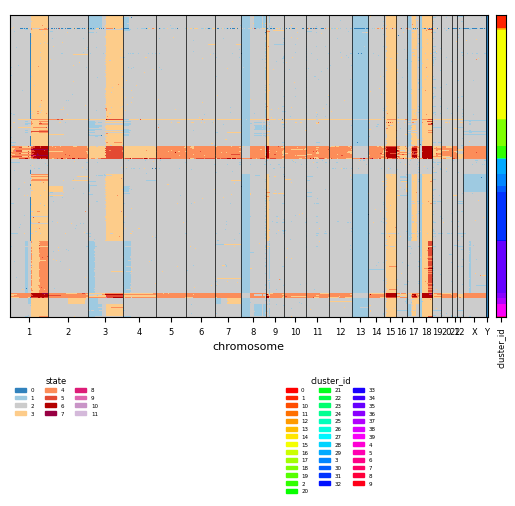

In [4]:
g = pl.plot_cell_cn_matrix_fig(adata, cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'])

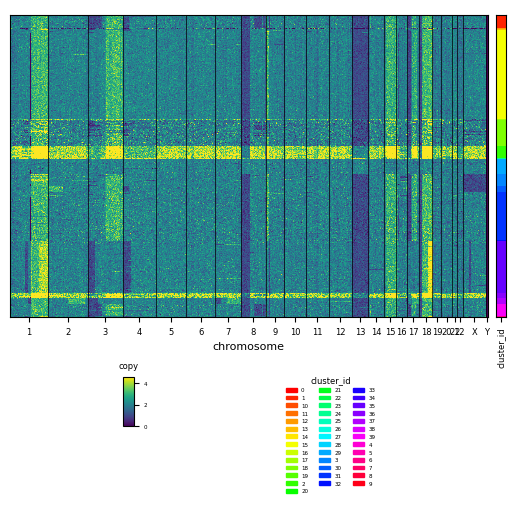

In [5]:
perc_98 = np.nanquantile(adata.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(adata, layer_name='copy', cell_order_fields=['cluster_id'], annotation_fields=['cluster_id'], raw=True, vmax=perc_98)

### Zoom on WGD cells

In [6]:
adata[adata.obs['mean_ploidy'] > 3]

View of AnnData object with n_obs × n_vars = 138 × 5298
    obs: 'cell_id', 'effective_depth_of_coverage', 'effective_reads_per_1Mbp', 'est_cnv_resolution_mb', 'frac_mapped_duplicates', 'is_high_dimapd', 'is_noisy', 'mean_ploidy', 'normalized_dimapd', 'normalized_mapd', 'num_duplicate_reads', 'num_lowmapq_reads', 'num_mapped_dedup_reads', 'num_unmapped_reads', 'ploidy_confidence', 'raw_dimapd', 'raw_mapd', 'total_num_reads', 'state_mean', 'state_var', 'is_normal', 'patient_id', 'dataset', 'description', 'cluster_id', 'cluster_size', 'cell_order'
    var: 'chr', 'start', 'end', 'gc_fraction', 'cyto_band_name', 'cyto_band_giemsa_stain'
    uns: 'clustering'
    layers: 'copy', 'normalized_counts', 'state'

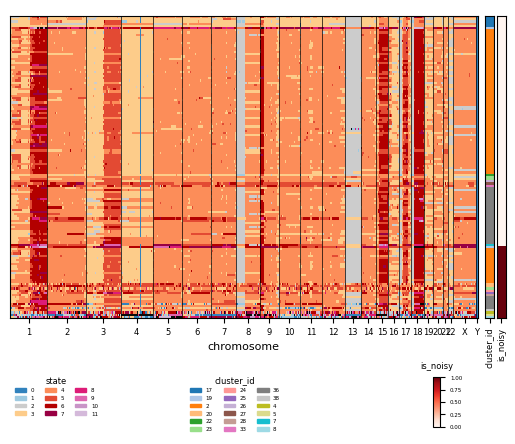

In [7]:
perc_99 = np.nanquantile(adata[(adata.obs['mean_ploidy'] > 3)].layers['copy'], .99)
# g = pl.plot_cell_cn_matrix_fig(adata[adata.obs['mean_ploidy'] > 3], layer_name='copy', cell_order_fields=['is_noisy', 'cluster_id'], annotation_fields=['cluster_id', 'is_noisy'], raw=True, vmax=perc_99)
g = pl.plot_cell_cn_matrix_fig(adata[adata.obs['mean_ploidy'] > 3], layer_name='state', cell_order_fields=['is_noisy', 'cluster_id'], annotation_fields=['cluster_id', 'is_noisy'])

In [15]:
# set adata to wgd dataset
adata = adata[(adata.obs['mean_ploidy'] > 3) & (~adata.obs['is_noisy'])].copy()

#### KMeans clustering

Keeping bins without nans: 5285 / 5298
Running KMeans with K=4
  Silhouette score: 0.4146
Running KMeans with K=5
  Silhouette score: 0.4164
Running KMeans with K=6
  Silhouette score: 0.2652
Running KMeans with K=7
  Silhouette score: 0.1990
Running KMeans with K=8
  Silhouette score: 0.1058
Running KMeans with K=9
  Silhouette score: 0.1200

Best K: 5 with silhouette score: 0.4164


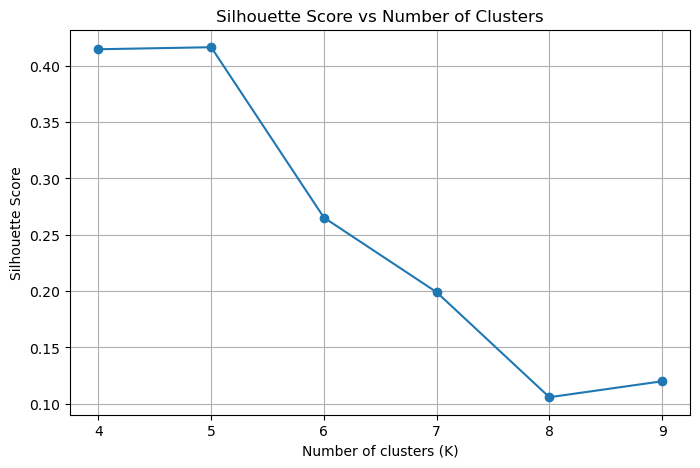

In [16]:
rerun_kmeans = True
if rerun_kmeans:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    kval = [4, 5, 6, 7, 8, 9]
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    print(f"Keeping bins without nans: {np.sum(valid_bins)} / {adata.n_vars}")
    cn_mat = adata[:, valid_bins].layers['state']

    silhouette_scores = []
    best_k = None
    best_score = -1
    best_labels = None

    for k in kval:
        print(f"Running KMeans with K={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(cn_mat)

        # Calculate silhouette score
        score = silhouette_score(cn_mat, labels)
        silhouette_scores.append(score)
        print(f"  Silhouette score: {score:.4f}")

        # Track best k
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"\nBest K: {best_k} with silhouette score: {best_score:.4f}")

    # Optional: visualize results
    import matplotlib.pyplot as plt
    plt.figure(figsize=(8, 5))
    plt.plot(kval, silhouette_scores, marker='o')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.grid(True)
    plt.show()

    # Store best clustering in adata
    adata.obs[f'kmeans_k{best_k}'] = best_labels
else:
    print("Best K: 9 with silhouette score: 0.4477")

#### Leiden clustering


Running Leiden with resolution=0.5
  Clusters: 3
  Silhouette: 0.0132
  Davies-Bouldin: 2.5614 (lower is better)
  Calinski-Harabasz: 7.87 (higher is better)

Running Leiden with resolution=0.7
  Clusters: 3
  Silhouette: 0.0132
  Davies-Bouldin: 2.5614 (lower is better)
  Calinski-Harabasz: 7.87 (higher is better)

Running Leiden with resolution=1.0
  Clusters: 3
  Silhouette: 0.0170
  Davies-Bouldin: 2.5687 (lower is better)
  Calinski-Harabasz: 7.92 (higher is better)

Running Leiden with resolution=1.5
  Clusters: 6
  Silhouette: -0.0918
  Davies-Bouldin: 2.4152 (lower is better)
  Calinski-Harabasz: 5.74 (higher is better)

Running Leiden with resolution=2.0
  Clusters: 10
  Silhouette: -0.1116
  Davies-Bouldin: 2.2861 (lower is better)
  Calinski-Harabasz: 4.20 (higher is better)

=== Summary ===
   resolution  n_clusters  silhouette  davies_bouldin  calinski_harabasz
0         0.5           3    0.013238        2.561387           7.868904
1         0.7           3    0.013238  

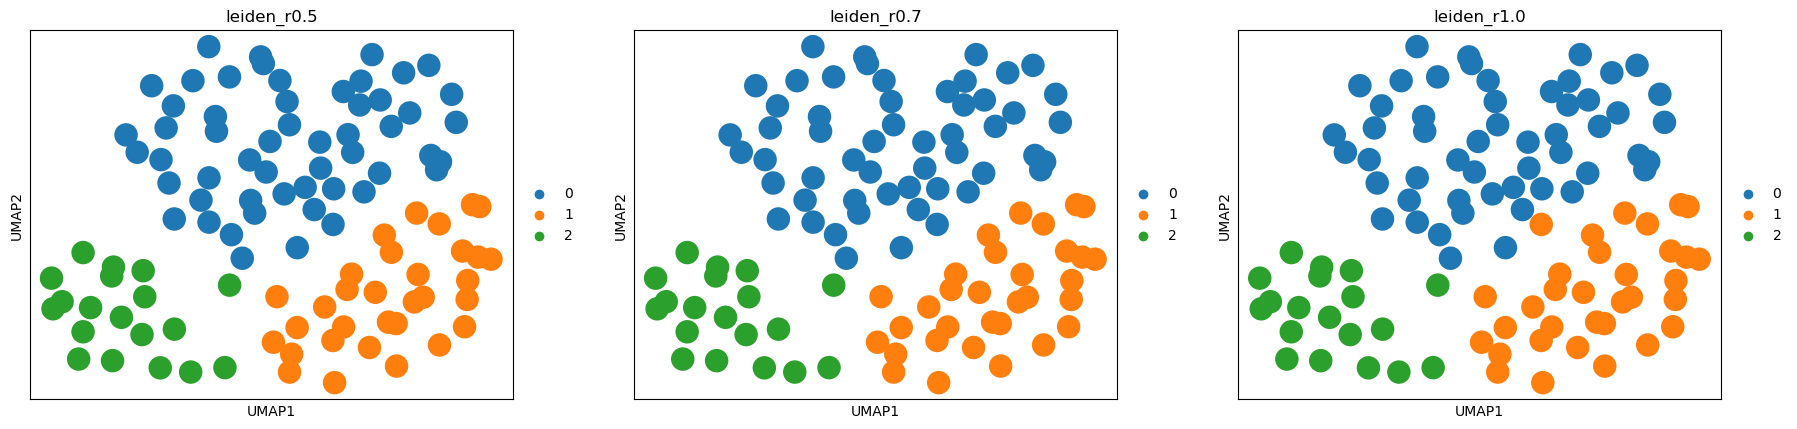

In [25]:
rerun_leiden = True
if rerun_leiden:
    import scanpy as sc
    import numpy as np

    # 1. First, compute neighbors on your CN state data (not the default adata.X)
    # Temporarily store filtered CN data in adata.X for neighbor computation
    valid_bins = ~np.any(np.isnan(adata.layers['state']), axis=0)
    adata_filt = adata[:, valid_bins].copy()
    adata_filt.X = adata_filt.layers['state']

    # 2. Compute neighbors on the CN data
    sc.pp.neighbors(adata_filt, n_neighbors=15, n_pcs=0, metric='manhattan')  # n_pcs=0 means use raw data, no PCA

    # 3. Try different resolutions and evaluate with multiple metrics
    resolutions = [0.5, 0.7, 1.0, 1.5, 2.0]
    results = []

    for res in resolutions:
        print(f"\nRunning Leiden with resolution={res}")
        sc.tl.leiden(adata_filt, resolution=res, key_added=f'leiden_r{res}')

        labels = adata_filt.obs[f'leiden_r{res}'].astype('category').cat.codes.values
        n_clusters = len(np.unique(labels))

        # Calculate multiple metrics
        from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

        sil_score = silhouette_score(adata_filt.X, labels)
        db_score = davies_bouldin_score(adata_filt.X, labels)  # Lower is better
        ch_score = calinski_harabasz_score(adata_filt.X, labels)  # Higher is better

        adata.obs[f'leiden_r{res}'] = labels

        results.append({
            'resolution': res,
            'n_clusters': n_clusters,
            'silhouette': sil_score,
            'davies_bouldin': db_score,
            'calinski_harabasz': ch_score
        })

        print(f"  Clusters: {n_clusters}")
        print(f"  Silhouette: {sil_score:.4f}")
        print(f"  Davies-Bouldin: {db_score:.4f} (lower is better)")
        print(f"  Calinski-Harabasz: {ch_score:.2f} (higher is better)")


    # 5. Summary and best resolution selection
    import pandas as pd
    results_df = pd.DataFrame(results)
    print("\n=== Summary ===")
    print(results_df)

    # Best by different metrics
    best_sil = results_df.loc[results_df['silhouette'].idxmax()]
    best_db = results_df.loc[results_df['davies_bouldin'].idxmin()]
    best_ch = results_df.loc[results_df['calinski_harabasz'].idxmax()]

    print(f"\nBest by Silhouette: resolution={best_sil['resolution']}, score={best_sil['silhouette']:.4f}")
    print(f"Best by Davies-Bouldin: resolution={best_db['resolution']}, score={best_db['davies_bouldin']:.4f}")
    print(f"Best by Calinski-Harabasz: resolution={best_ch['resolution']}, score={best_ch['calinski_harabasz']:.2f}")
    # 6. Optional: Visualize if you have UMAP/PCA
    sc.tl.umap(adata_filt)
    sc.pl.umap(adata_filt, color=[f'leiden_r{r}' for r in [0.5, 0.7, 1.0]])#%% md
else:
    print("Not run yet")

#### Conclusions
Both clustering methods find very poor clustering, therefore we can conclude that this dataset, despite the motivation, is just trash (it doesn't suit our purposes)

### Cellmates tree

In [12]:
import os
import io
from Bio import Phylo

cm_out_dir = "/home/vittorio.zampinetti/cellmates_res/real_data/MM_03_cm_out"
cell_names = open(os.path.join(cm_out_dir, "cell_names.txt")).read().splitlines()
tree_nwk = open(os.path.join(cm_out_dir, "tree.nwk")).read().strip()
nx_tree = newick_to_nx(tree_nwk)
bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree, weight=None)), "newick")
# bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(nx_tree, weight='weight')), "newick")
print(tree_nwk)
print(len(cell_names), adata[cell_names].n_obs)
print(cell_names, adata[cell_names].obs.index.tolist())

(TCATTACAGCGTAATA-1:0.0005274156477631791,(CGCGGTACATAGGTCT-1:0.002233543106343743,((GCTGGGTCACGGAGTA-1:0.0006139316363010664,(AAGTCTGCACAAGGAC-1:0.0008240545668808146,((GGAAAGCTCTGGTGAT-1:0.0006892589925281279,TCAGATGTCTACAGTG-1:0.00032218048498099995)ancestor7:0.0005217955464230354,((AAACGGGTCGCTAGTA-1:0.0011257397227152938,((GGCTCGATCAAAGTGA-1:0.000638247842160521,(CGACCTTTCCGCACGA-1:0.0014904037476923249,(GGGAATGAGCTAAGAT-1:0.001424563485500808,(GTCTCGTAGCAGTAGC-1:0.003764855362226396,(CAACCTCGTGATACCT-1:0.004215220872732085,(CAACCTCAGCTCTCGG-1:0.0013033466948416767,(GATCTAGAGAAACCCG-1:0.009469821736218614,(((ACCAGTATCCATTTGT-1:0.0021100936433394325,CCGGGATTCTCAGCGG-1:0.002708496931448227)ancestor51:0.0007909567775417729,(CCGTTCAAGAAACGCC-1:0.0026654123702211656,(CACCTTGGTGAACACG-1:0.00563503546816921,CTTCTCTAGCCAACAG-1:0.005710853683617822)ancestor58:0.0010755134411590851)ancestor52:0.0003723853012211342)ancestor45:0.0009693207544168268,(CGCCAAGCAGGTTAAA-1:0.01783423877638846,(CAG

In [26]:
# clustering_lab = 'leiden_r0.5'
clustering_lab = 'kmeans_k5'

/home/vittorio.zampinetti/miniforge3/envs/cellmates/lib/python3.10/site-packages/scgenome/plotting/heatmap.py:394: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['phylo_order'] = -1


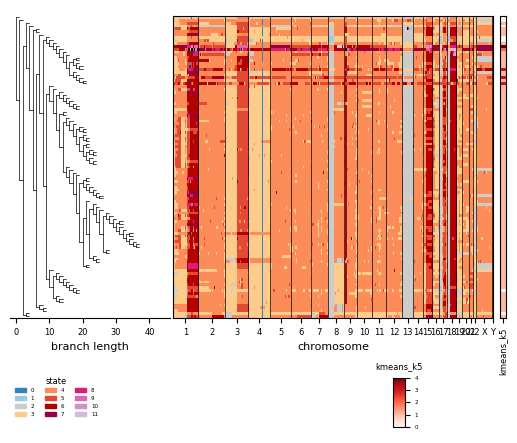

In [27]:
g = pl.plot_cell_cn_matrix_fig(adata[cell_names], layer_name='state', tree=bio_tree, annotation_fields=[clustering_lab])

In [28]:
nx_tree = relabel_name_to_int(nx_tree, cell_names)
dpy_tree = convert_networkx_to_dendropy(nx_tree, edge_length='weight')
f1_score = f1_score_clades(dpy_tree, adata[cell_names].obs[clustering_lab])

In [29]:
f1_score

0.42281179138321995

### MEDICC2

In [30]:
medicc_adata = anndata.read_h5ad(os.path.join(cm_out_dir, "medicc2", "MM03_medicc2_output.h5ad"))
medicc_adata_cells = medicc_adata[cell_names].copy()
medicc_adata_cells.obs[clustering_lab] = adata[medicc_adata_cells.obs_names].obs[clustering_lab]
medicc_adata_cells.layers['copy'] = adata[medicc_adata_cells.obs_names, medicc_adata_cells.var_names].layers['copy']
medicc_adata_cells

AnnData object with n_obs × n_vars = 105 × 5298
    obs: 'is_ancestor', 'branch_length', 'kmeans_k5'
    var: 'chrom', 'start', 'end'
    uns: 'medicc2_pairwise_distances', 'medicc2_summary', 'medicc2_tree_newick'
    layers: 'copy'

In [35]:
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chrom']
#manipulate chr
chr_codes = {c: c[3:] for c in medicc_adata_cells.var['chr'].unique()}
medicc_adata_cells.var['chr'] = medicc_adata_cells.var['chr'].map(chr_codes)

In [36]:
# CONVERT MEDICC TREE TO BIO TREE
# need to re-root so to include only the tumor cells
# internal_7 was found by printing the successors of 'diploid' ancestor (that is 'None')
med_tree_nwk = medicc_adata_cells.uns['medicc2_tree_newick']
med_nx_tree = newick_to_nx(med_tree_nwk)
edges = [(u, v, med_nx_tree.edges[u,v]['weight']) for (u, v) in nx.dfs_tree(med_nx_tree, 'internal_7').edges]
med_nx_tree = nx.DiGraph()
med_nx_tree.add_weighted_edges_from(edges)
# print([(n, nx.ancestors(med_nx_tree, n)) for n in med_nx_tree.nodes if (med_nx_tree.out_degree(n) == 0 and n not in cell_names)])
# print(list(med_nx_tree.successors('None')))
med_bio_tree = Phylo.read(io.StringIO(nxtree_to_newick(med_nx_tree)), format="newick")
med_nx_tree = relabel_name_to_int(med_nx_tree, cell_names)
med_dpy_tree = convert_networkx_to_dendropy(med_nx_tree, edge_length='weight', taxon_namespace=dpy_tree.taxon_namespace)
med_f1_score = f1_score_clades(med_dpy_tree, medicc_adata_cells.obs[clustering_lab])

In [37]:
med_f1_score

0.6591800356506238

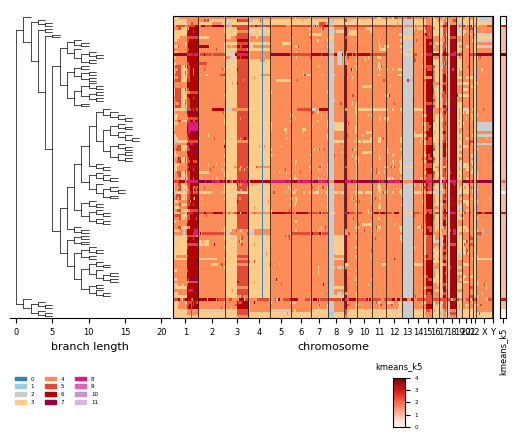

In [38]:
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name=None, tree=med_bio_tree, annotation_fields=[clustering_lab])

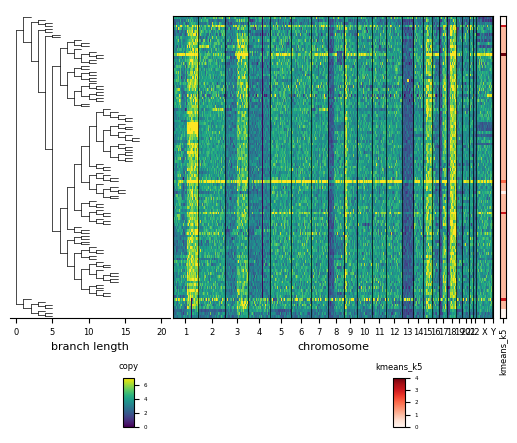

In [40]:
perc_98 = np.nanquantile(medicc_adata_cells.layers['copy'], .98)
g = pl.plot_cell_cn_matrix_fig(medicc_adata_cells, layer_name='copy', tree=med_bio_tree, annotation_fields=[clustering_lab], raw=True, vmax=perc_98)

In [41]:
# compare trees with RF
normalized_rf_distance(dpy_tree, med_dpy_tree)

0.9805825242718447